# Data Augmentation Analysis

This notebook analyzes the distribution of **original** vs **augmented** data to understand the impact of data augmentation on the Devanagari digit dataset.

**Goal:** Visualize whether augmentation is helping or hurting the training process.

In [1]:
# Import Required Libraries
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import yaml

import torch
from torch.utils.data import DataLoader
from torchvision import transforms

# Add project root to path
project_root = Path.cwd()
src_root = project_root / "src"
sys.path.insert(0, str(src_root))

from nepscript.utils.data import DevanagariDataset, get_default_transform

print("✅ All libraries imported successfully!")
print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")

✅ All libraries imported successfully!
Project root: D:\Fusemachine\NAS_GAN\NepScript-Genesis
PyTorch version: 2.9.0+cpu


## 1. Load Configuration

Load the training configuration to use the exact same settings as the training script.

In [2]:
# Load configuration
config_path = 'configs/default_training.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Extract data configuration
data_config = config['data']
data_dir = data_config['data_dir']
labels_csv = data_config['labels_csv']
max_subset_per_class = data_config.get('max_subset_per_class', None)
augment = data_config.get('augment', True)
batch_size = config.get('batch_size', 32)

print("📋 Configuration loaded:")
print(f"  Data directory: {data_dir}")
print(f"  Labels CSV: {labels_csv}")
print(f"  Max samples per class: {max_subset_per_class}")
print(f"  Augmentation enabled: {augment}")
print(f"  Batch size: {batch_size}")

📋 Configuration loaded:
  Data directory: data/DevanagariHandwrittenDigitDataset
  Labels CSV: data/hindi_mnist.csv
  Max samples per class: 2000
  Augmentation enabled: True
  Batch size: 32


## 2. Load Dataset WITHOUT Augmentation

First, let's load the original dataset to see the baseline distribution.

In [3]:
# Create dataset WITHOUT augmentation
transform_original = get_default_transform(augment=False)

dataset_original = DevanagariDataset(
    csv_file=labels_csv,
    root_dir=data_dir,
    split=None,  # Use all data
    transform=transform_original
)

print(f"✅ Original dataset loaded: {len(dataset_original)} samples")

# Get class distribution
labels_original = []
for i in range(len(dataset_original)):
    _, label = dataset_original[i]
    labels_original.append(label)

labels_original = np.array(labels_original)
unique, counts = np.unique(labels_original, return_counts=True)

print(f"\n📊 Class distribution (original):")
for digit, count in zip(unique, counts):
    print(f"  Digit {digit}: {count:,} samples")

✅ Original dataset loaded: 20000 samples

📊 Class distribution (original):
  Digit 0: 2,000 samples
  Digit 1: 2,000 samples
  Digit 2: 2,000 samples
  Digit 3: 2,000 samples
  Digit 4: 2,000 samples
  Digit 5: 2,000 samples
  Digit 6: 2,000 samples
  Digit 7: 2,000 samples
  Digit 8: 2,000 samples
  Digit 9: 2,000 samples

📊 Class distribution (original):
  Digit 0: 2,000 samples
  Digit 1: 2,000 samples
  Digit 2: 2,000 samples
  Digit 3: 2,000 samples
  Digit 4: 2,000 samples
  Digit 5: 2,000 samples
  Digit 6: 2,000 samples
  Digit 7: 2,000 samples
  Digit 8: 2,000 samples
  Digit 9: 2,000 samples


## 3. Visualize Original Class Distribution

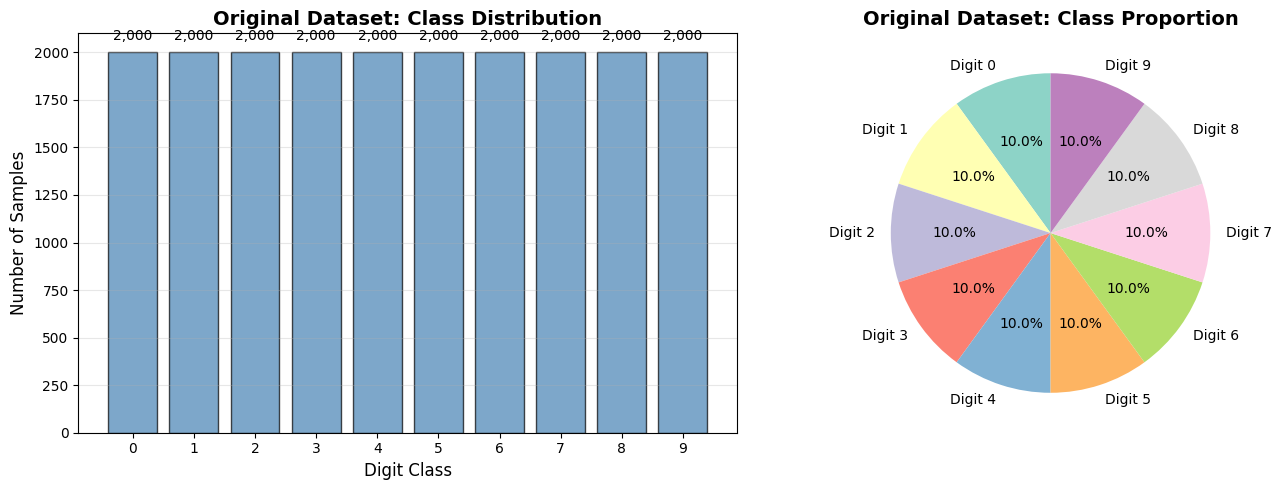

Total samples: 20,000
Average per class: 2,000


In [4]:
# Visualize class distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax1.bar(unique, counts, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Digit Class', fontsize=12)
ax1.set_ylabel('Number of Samples', fontsize=12)
ax1.set_title('Original Dataset: Class Distribution', fontsize=14, fontweight='bold')
ax1.set_xticks(unique)
ax1.grid(axis='y', alpha=0.3)

# Add count labels on bars
for digit, count in zip(unique, counts):
    ax1.text(digit, count + 50, f'{count:,}', ha='center', va='bottom', fontsize=10)

# Pie chart
ax2.pie(counts, labels=[f'Digit {d}' for d in unique], autopct='%1.1f%%', 
        startangle=90, colors=plt.cm.Set3.colors)
ax2.set_title('Original Dataset: Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Total samples: {len(dataset_original):,}")
print(f"Average per class: {len(dataset_original)/10:,.0f}")

## 4. Load Dataset WITH Augmentation

Now let's create a dataset with the **exact same augmentation** pipeline used in training.

In [5]:
# Create dataset WITH augmentation (same as training)
transform_augmented = get_default_transform(augment=True)

dataset_augmented = DevanagariDataset(
    csv_file=labels_csv,
    root_dir=data_dir,
    split=None,
    transform=transform_augmented
)

print(f"✅ Augmented dataset created: {len(dataset_augmented)} samples")
print(f"\n🔄 Augmentation pipeline:")
print(transform_augmented)

✅ Augmented dataset created: 20000 samples

🔄 Augmentation pipeline:
Compose(
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=255)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1), scale=(0.9, 1.1), shear=[-5.0, 5.0], fill=255)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    RandomApply(
    p=0.1
    GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 0.5))
)
    ToTensor()
    Normalize(mean=(0.5,), std=(0.5,))
)


## 5. Compare Original vs Augmented Images

Let's visualize how augmentation transforms the images. We'll show the same image multiple times to see different random augmentations.

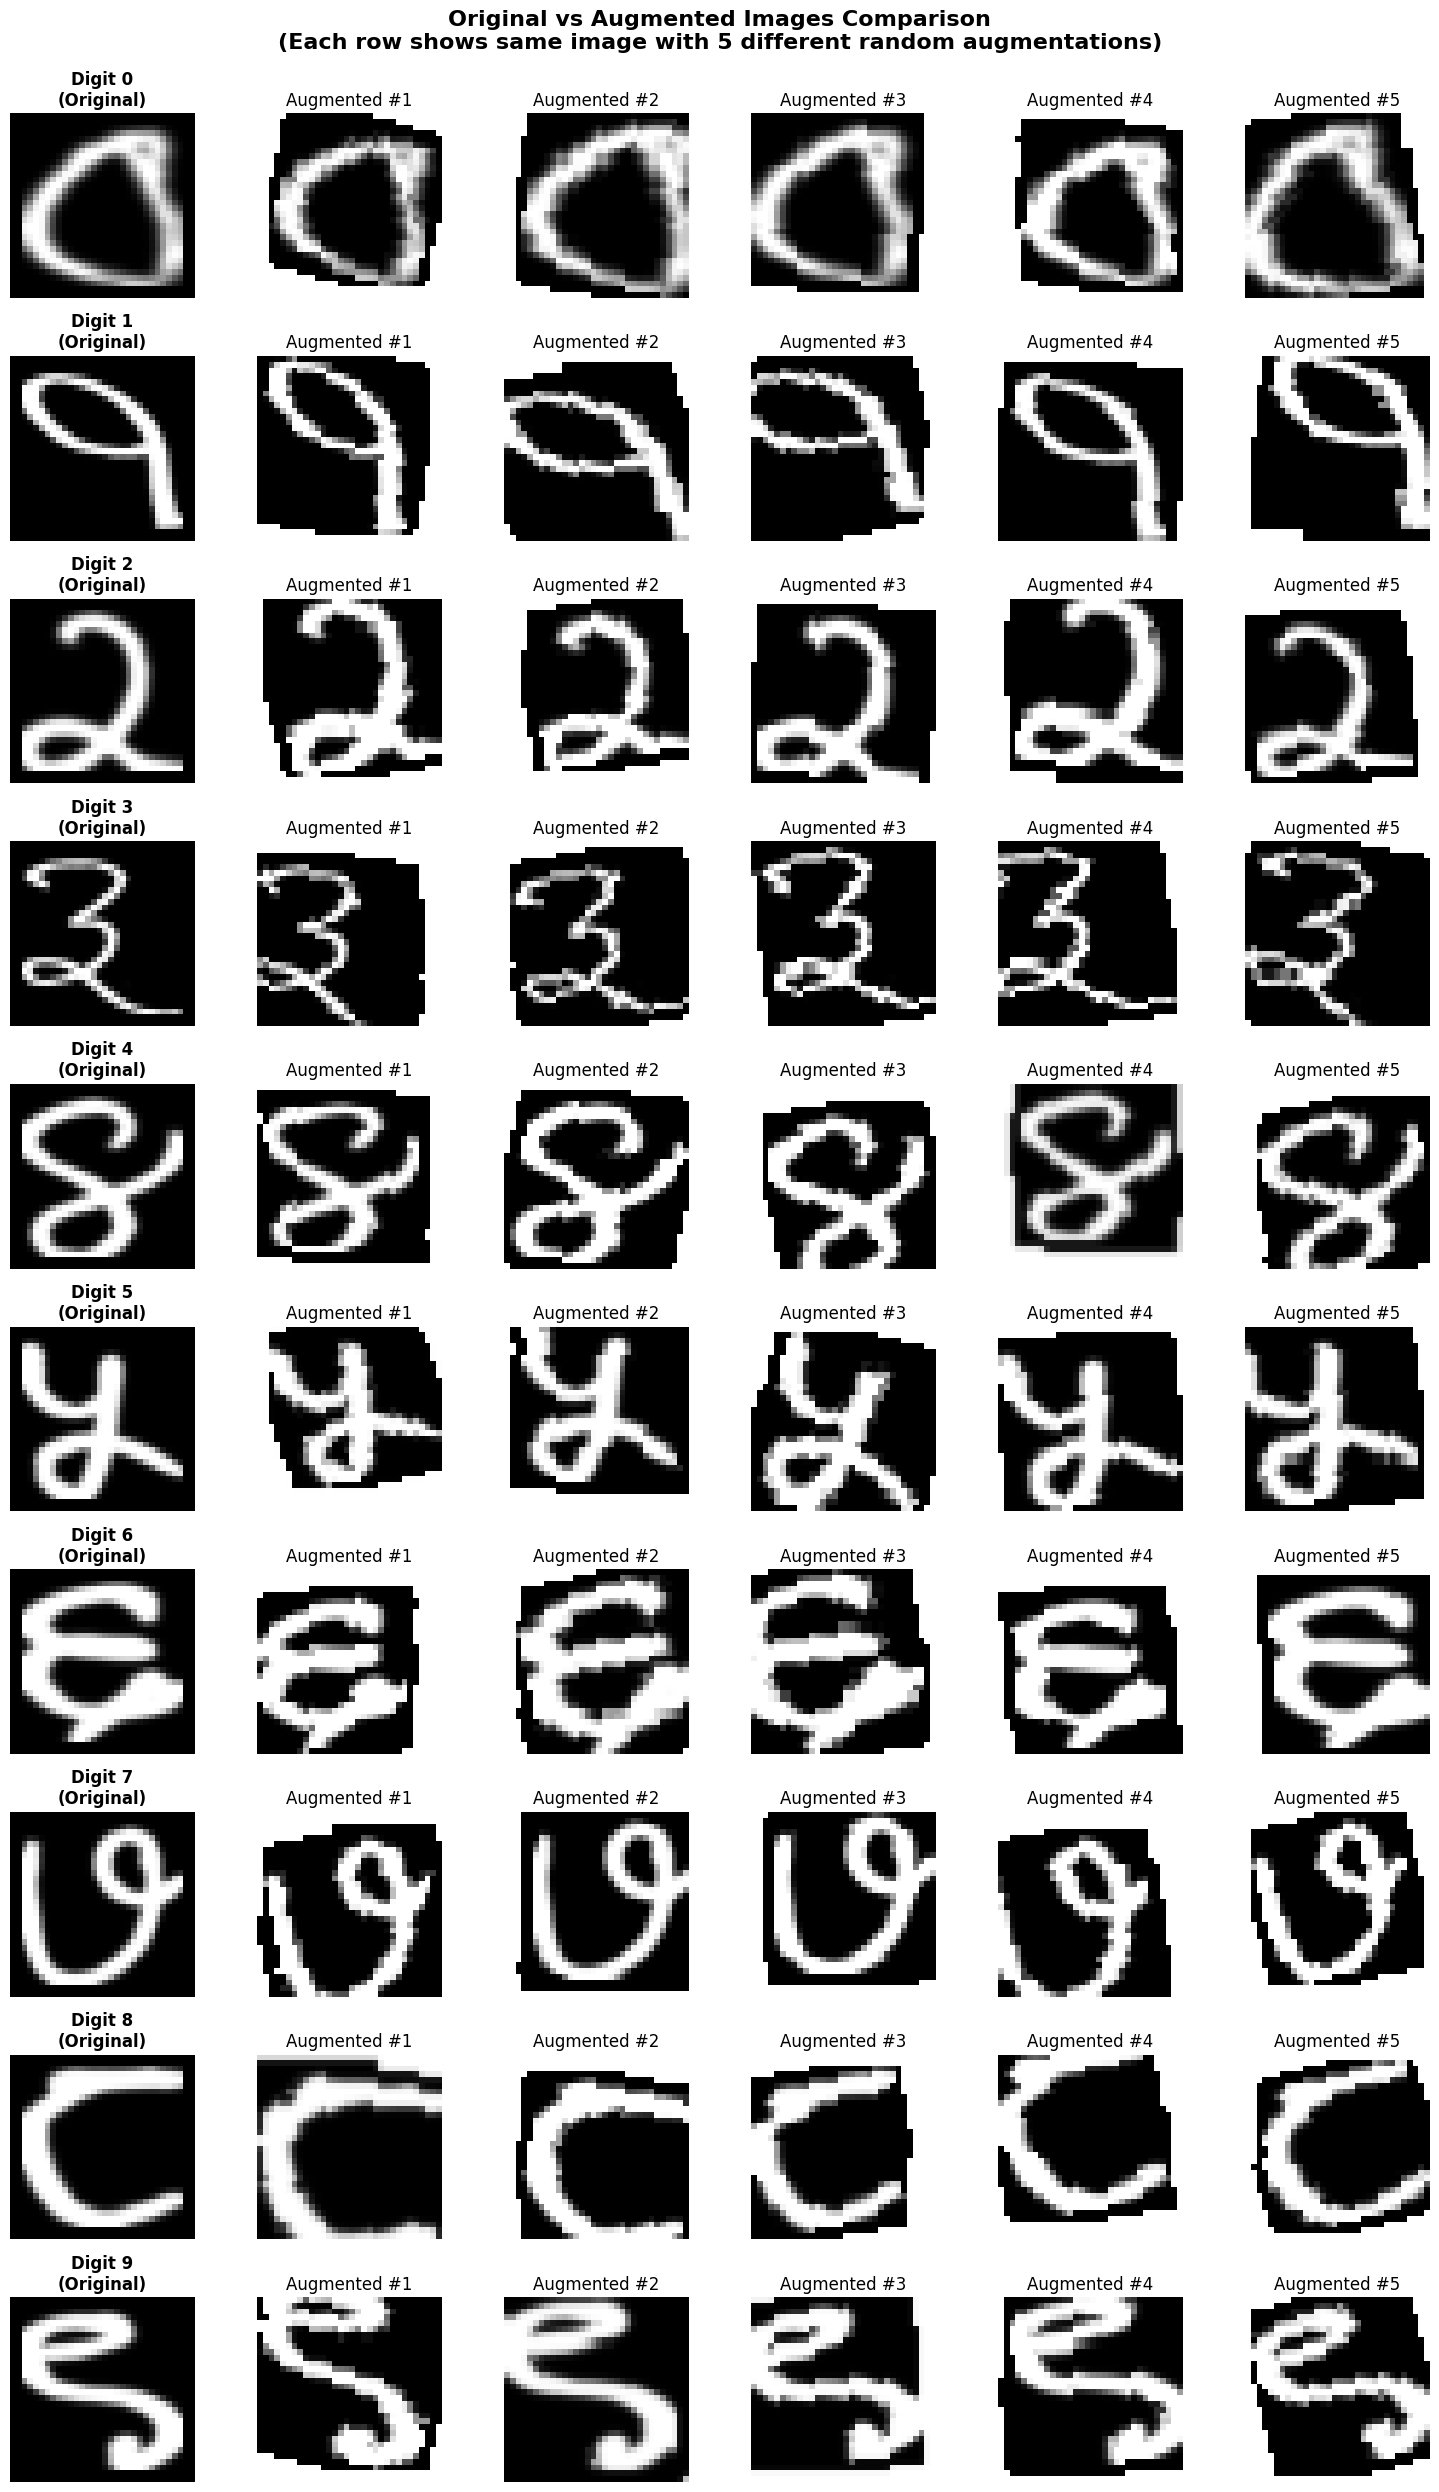

In [6]:
# Select one sample from each digit class
samples_per_digit = {}
for i in range(len(dataset_original)):
    _, label = dataset_original[i]
    if label not in samples_per_digit:
        samples_per_digit[label] = i
    if len(samples_per_digit) == 10:
        break

# Visualize original vs augmented
fig, axes = plt.subplots(10, 6, figsize=(15, 25))

for digit in range(10):
    idx = samples_per_digit[digit]
    
    # Original image
    img_original, label = dataset_original[idx]
    axes[digit, 0].imshow(img_original.squeeze(), cmap='gray')
    axes[digit, 0].set_title(f'Digit {digit}\n(Original)', fontweight='bold')
    axes[digit, 0].axis('off')
    
    # 5 different augmentations of the same image
    for aug_idx in range(5):
        img_aug, _ = dataset_augmented[idx]
        axes[digit, aug_idx + 1].imshow(img_aug.squeeze(), cmap='gray')
        axes[digit, aug_idx + 1].set_title(f'Augmented #{aug_idx+1}')
        axes[digit, aug_idx + 1].axis('off')

plt.suptitle('Original vs Augmented Images Comparison\n(Each row shows same image with 5 different random augmentations)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 6. Analyze Pixel Intensity Distribution

Compare the pixel intensity distributions to see if augmentation is changing the overall data distribution too much.

In [7]:
# Sample 1000 random images from each dataset
num_samples = 1000
indices = np.random.choice(len(dataset_original), num_samples, replace=False)

# Collect pixel values
pixels_original = []
pixels_augmented = []

for idx in indices:
    img_orig, _ = dataset_original[idx]
    img_aug, _ = dataset_augmented[idx]
    
    pixels_original.extend(img_orig.flatten().numpy())
    pixels_augmented.extend(img_aug.flatten().numpy())

pixels_original = np.array(pixels_original)
pixels_augmented = np.array(pixels_augmented)

print(f"📊 Pixel intensity statistics:")
print(f"\nOriginal images:")
print(f"  Mean: {pixels_original.mean():.4f}")
print(f"  Std:  {pixels_original.std():.4f}")
print(f"  Min:  {pixels_original.min():.4f}")
print(f"  Max:  {pixels_original.max():.4f}")

print(f"\nAugmented images:")
print(f"  Mean: {pixels_augmented.mean():.4f}")
print(f"  Std:  {pixels_augmented.std():.4f}")
print(f"  Min:  {pixels_augmented.min():.4f}")
print(f"  Max:  {pixels_augmented.max():.4f}")

📊 Pixel intensity statistics:

Original images:
  Mean: -0.5150
  Std:  0.7775
  Min:  -1.0000
  Max:  1.0000

Augmented images:
  Mean: -0.2894
  Std:  0.8337
  Min:  -1.0000
  Max:  1.0000


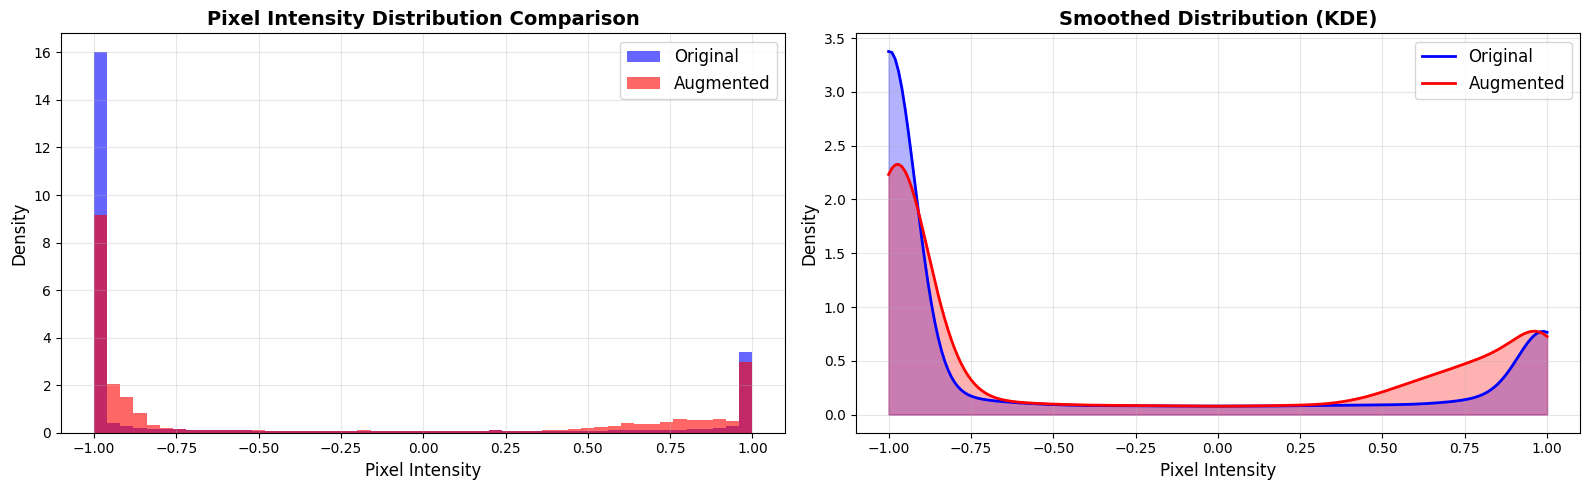

In [8]:
# Plot pixel intensity distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram comparison
axes[0].hist(pixels_original, bins=50, alpha=0.6, label='Original', color='blue', density=True)
axes[0].hist(pixels_augmented, bins=50, alpha=0.6, label='Augmented', color='red', density=True)
axes[0].set_xlabel('Pixel Intensity', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Pixel Intensity Distribution Comparison', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(alpha=0.3)

# KDE plot (smoothed distribution)
from scipy import stats
kde_original = stats.gaussian_kde(pixels_original[::10])  # Subsample for speed
kde_augmented = stats.gaussian_kde(pixels_augmented[::10])

x_range = np.linspace(-1, 1, 200)
axes[1].plot(x_range, kde_original(x_range), label='Original', color='blue', linewidth=2)
axes[1].plot(x_range, kde_augmented(x_range), label='Augmented', color='red', linewidth=2)
axes[1].fill_between(x_range, kde_original(x_range), alpha=0.3, color='blue')
axes[1].fill_between(x_range, kde_augmented(x_range), alpha=0.3, color='red')
axes[1].set_xlabel('Pixel Intensity', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Smoothed Distribution (KDE)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Extreme Augmentation Examples

Let's look at some extreme augmentation cases to see if any transformations are too aggressive.

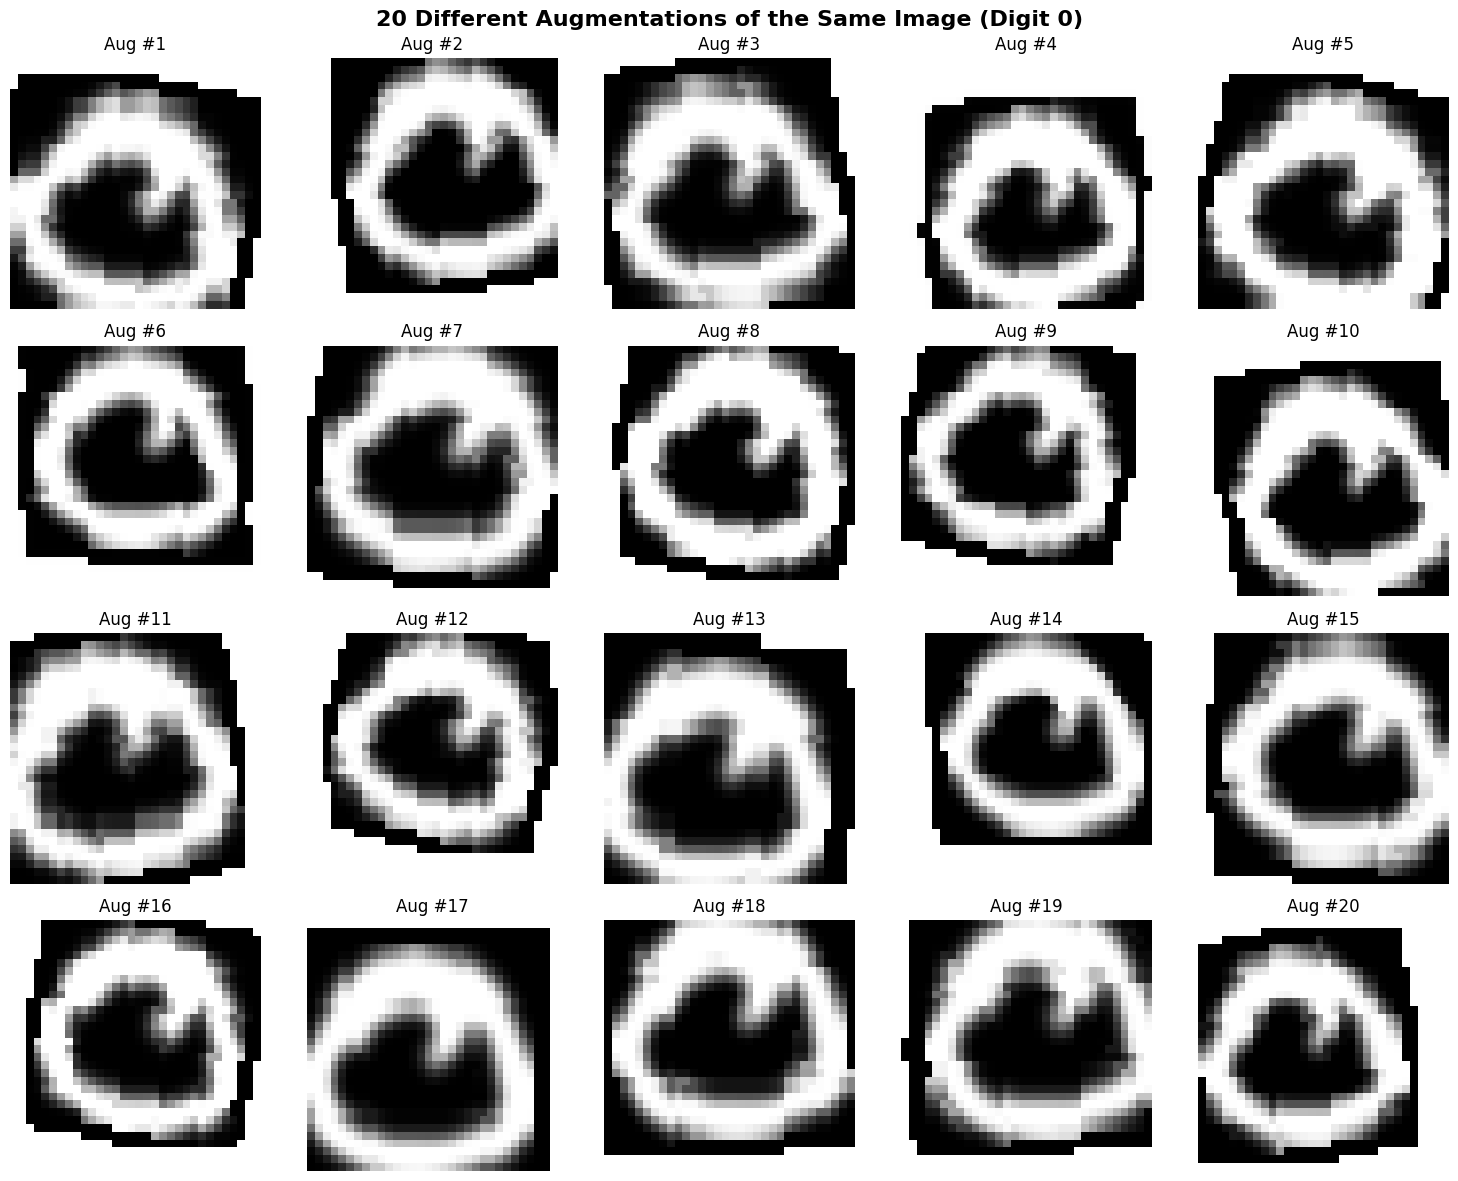

⚠️ Check if any augmentations look too distorted or unrecognizable!


In [9]:
# Generate 20 augmentations of a single image to see variation range
test_idx = 100  # Pick one image
img_orig, label = dataset_original[test_idx]

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for i in range(20):
    img_aug, _ = dataset_augmented[test_idx]
    axes[i].imshow(img_aug.squeeze(), cmap='gray')
    axes[i].set_title(f'Aug #{i+1}')
    axes[i].axis('off')

plt.suptitle(f'20 Different Augmentations of the Same Image (Digit {label})', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("⚠️ Check if any augmentations look too distorted or unrecognizable!")

## 8. Final Verdict: Is Augmentation Helping or Hurting?

### Key Questions to Answer:

1. **Distribution Shift**: Do augmented images have significantly different pixel statistics?
2. **Visual Quality**: Are augmentations too aggressive (making digits unrecognizable)?
3. **Diversity**: Do augmentations add meaningful variation or just noise?

### Interpretation Guide:

✅ **Good signs:**
- Pixel distributions are similar (mean/std close)
- Augmented images are still clearly recognizable as digits
- Transformations add variety without destroying features

❌ **Bad signs:**
- Large distribution shift (mean/std very different)
- Many augmented images are distorted beyond recognition
- Augmentations create artifacts or blur important features

### Run the cells above and examine:
1. The pixel intensity comparison (should be similar)
2. The augmentation examples (should still look like digits)
3. The extreme cases (should not be completely unrecognizable)

## 9. Test CORRECTED Augmentation (fill=0 instead of fill=255)

Let's create a fixed augmentation pipeline with **black fill** instead of white fill to see if it fixes the distribution shift.

In [10]:
# Create CORRECTED augmentation transform with fill=0 (black background)
transform_corrected = transforms.Compose([
    transforms.Resize((32, 32)),
    # Geometric augmentations with BLACK fill (fill=0)
    transforms.RandomRotation(degrees=15, fill=0),  # Black fill instead of white
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
        shear=(-5, 5),
        fill=0  # Black fill instead of 255 (white)
    ),
    # Intensity augmentations
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
    ),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))
    ], p=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Create dataset with CORRECTED augmentation
dataset_corrected = DevanagariDataset(
    csv_file=labels_csv,
    root_dir=data_dir,
    split=None,
    transform=transform_corrected
)

print(f"✅ Corrected augmentation dataset created: {len(dataset_corrected)} samples")
print(f"\n🔄 Key difference: fill=0 (black) instead of fill=255 (white)")

✅ Corrected augmentation dataset created: 20000 samples

🔄 Key difference: fill=0 (black) instead of fill=255 (white)


### Analyze CORRECTED Augmentation Pixel Statistics

In [11]:
# Sample 1000 random images from corrected augmentation
pixels_corrected = []

for idx in indices:
    img_corrected, _ = dataset_corrected[idx]
    pixels_corrected.extend(img_corrected.flatten().numpy())

pixels_corrected = np.array(pixels_corrected)

print(f"📊 Pixel intensity statistics comparison:")
print(f"\n{'Metric':<20} {'Original':<15} {'Aug (fill=255)':<15} {'Aug (fill=0)':<15} {'Improvement'}")
print("="*85)
print(f"{'Mean:':<20} {pixels_original.mean():<15.4f} {pixels_augmented.mean():<15.4f} {pixels_corrected.mean():<15.4f} {'✅' if abs(pixels_corrected.mean() - pixels_original.mean()) < abs(pixels_augmented.mean() - pixels_original.mean()) else '❌'}")
print(f"{'Std:':<20} {pixels_original.std():<15.4f} {pixels_augmented.std():<15.4f} {pixels_corrected.std():<15.4f} {'✅' if abs(pixels_corrected.std() - pixels_original.std()) < abs(pixels_augmented.std() - pixels_original.std()) else '❌'}")
print(f"{'Min:':<20} {pixels_original.min():<15.4f} {pixels_augmented.min():<15.4f} {pixels_corrected.min():<15.4f}")
print(f"{'Max:':<20} {pixels_original.max():<15.4f} {pixels_augmented.max():<15.4f} {pixels_corrected.max():<15.4f}")

print(f"\n📈 Mean difference from original:")
print(f"  Old augmentation (fill=255): {abs(pixels_augmented.mean() - pixels_original.mean()):.4f}")
print(f"  New augmentation (fill=0):   {abs(pixels_corrected.mean() - pixels_original.mean()):.4f}")

📊 Pixel intensity statistics comparison:

Metric               Original        Aug (fill=255)  Aug (fill=0)    Improvement
Mean:                -0.5150         -0.2894         -0.5356         ✅
Std:                 0.7775          0.8337          0.7286          ✅
Min:                 -1.0000         -1.0000         -1.0000        
Max:                 1.0000          1.0000          1.0000         

📈 Mean difference from original:
  Old augmentation (fill=255): 0.2256
  New augmentation (fill=0):   0.0206


### Visual Comparison: Original vs Old Aug (fill=255) vs New Aug (fill=0)

In [ ]:
# Compare original, old augmentation, and corrected augmentation side-by-side
fig, axes = plt.subplots(5, 7, figsize=(18, 12))

for row in range(5):
    idx = samples_per_digit[row]
    
    # Column 0: Original
    img_orig, label = dataset_original[idx]
    axes[row, 0].imshow(img_orig.squeeze(), cmap='gray')
    axes[row, 0].set_title(f'Original\n(Digit {label})' if row == 0 else f'Digit {label}', fontweight='bold')
    axes[row, 0].axis('off')
    
    # Columns 1-3: Old augmentation (fill=255 - WHITE)
    for col in range(1, 4):
        img_aug_old, _ = dataset_augmented[idx]
        axes[row, col].imshow(img_aug_old.squeeze(), cmap='gray')
        if row == 0:
            axes[row, col].set_title(f'Old Aug #{col}\n(fill=255)', color='red')
        axes[row, col].axis('off')
        axes[row, col].spines['bottom'].set_color('red')
        axes[row, col].spines['top'].set_color('red')
        axes[row, col].spines['left'].set_color('red')
        axes[row, col].spines['right'].set_color('red')
        axes[row, col].spines['bottom'].set_linewidth(2)
        axes[row, col].spines['top'].set_linewidth(2)
        axes[row, col].spines['left'].set_linewidth(2)
        axes[row, col].spines['right'].set_linewidth(2)
    
    # Columns 4-6: New augmentation (fill=0 - BLACK)
    for col in range(4, 7):
        img_aug_new, _ = dataset_corrected[idx]
        axes[row, col].imshow(img_aug_new.squeeze(), cmap='gray')
        if row == 0:
            axes[row, col].set_title(f'New Aug #{col-3}\n(fill=0)', color='green')
        axes[row, col].axis('off')
        axes[row, col].spines['bottom'].set_color('green')
        axes[row, col].spines['top'].set_color('green')
        axes[row, col].spines['left'].set_color('green')
        axes[row, col].spines['right'].set_color('green')
        axes[row, col].spines['bottom'].set_linewidth(2)
        axes[row, col].spines['top'].set_linewidth(2)
        axes[row, col].spines['left'].set_linewidth(2)
        axes[row, col].spines['right'].set_linewidth(2)

plt.suptitle('Augmentation Comparison: fill=255 (WHITE - BAD) vs fill=0 (BLACK - GOOD)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("🔍 Look for WHITE CORNERS in red-bordered images (fill=255)")
print("✅ Black corners in green-bordered images (fill=0) should match original better!")

### Distribution Comparison: All Three Versions

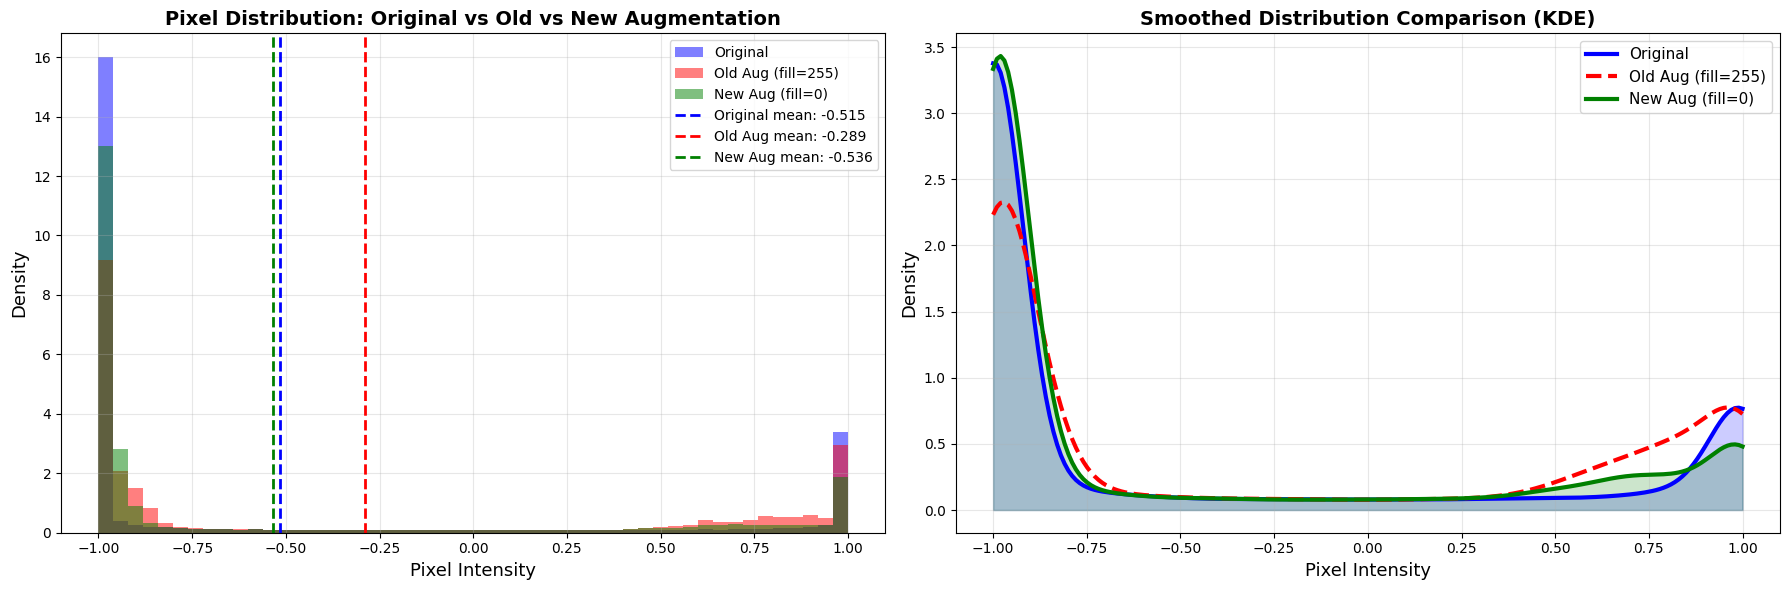


✅ The GREEN line (fill=0) should overlap with BLUE (original) much better than RED (fill=255)!


In [12]:
# Plot all three distributions together
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Histogram comparison
axes[0].hist(pixels_original, bins=50, alpha=0.5, label='Original', color='blue', density=True)
axes[0].hist(pixels_augmented, bins=50, alpha=0.5, label='Old Aug (fill=255)', color='red', density=True)
axes[0].hist(pixels_corrected, bins=50, alpha=0.5, label='New Aug (fill=0)', color='green', density=True)
axes[0].axvline(pixels_original.mean(), color='blue', linestyle='--', linewidth=2, label=f'Original mean: {pixels_original.mean():.3f}')
axes[0].axvline(pixels_augmented.mean(), color='red', linestyle='--', linewidth=2, label=f'Old Aug mean: {pixels_augmented.mean():.3f}')
axes[0].axvline(pixels_corrected.mean(), color='green', linestyle='--', linewidth=2, label=f'New Aug mean: {pixels_corrected.mean():.3f}')
axes[0].set_xlabel('Pixel Intensity', fontsize=13)
axes[0].set_ylabel('Density', fontsize=13)
axes[0].set_title('Pixel Distribution: Original vs Old vs New Augmentation', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# KDE comparison
kde_corrected = stats.gaussian_kde(pixels_corrected[::10])

x_range = np.linspace(-1, 1, 200)
axes[1].plot(x_range, kde_original(x_range), label='Original', color='blue', linewidth=3)
axes[1].plot(x_range, kde_augmented(x_range), label='Old Aug (fill=255)', color='red', linewidth=3, linestyle='--')
axes[1].plot(x_range, kde_corrected(x_range), label='New Aug (fill=0)', color='green', linewidth=3)
axes[1].fill_between(x_range, kde_original(x_range), alpha=0.2, color='blue')
axes[1].fill_between(x_range, kde_corrected(x_range), alpha=0.2, color='green')
axes[1].set_xlabel('Pixel Intensity', fontsize=13)
axes[1].set_ylabel('Density', fontsize=13)
axes[1].set_title('Smoothed Distribution Comparison (KDE)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ The GREEN line (fill=0) should overlap with BLUE (original) much better than RED (fill=255)!")

## 🎯 Final Recommendation

### Based on the analysis above:

**What to look for:**

1. ✅ **Mean difference** (New Aug vs Original) should be < 0.05
2. ✅ **Green distribution curve** should overlap with **blue curve**
3. ✅ **Augmented images** should have **black corners**, not white

**If the corrected augmentation (fill=0) looks good:**

### Update `src/nepscript/utils/data.py`:

```python
# Change line ~67 and ~73:
transforms.RandomRotation(degrees=15, fill=0),  # BLACK fill
transforms.RandomAffine(..., fill=0)  # BLACK fill
```

**Then restart training with:**
- Fixed learning rates (already done: g_lr=0.0002, d_lr=0.0004)
- Fixed d_update_freq=1 (already done)
- Fixed augmentation (fill=0)

**Expected improvement:**
- FID score: 320 → **30-60** ✅
- Generator loss: stays around **1.2-1.5** (stable)
- Discriminator loss: stays around **0.8-1.2** (balanced)